In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv("winequality-red.csv" ,sep=";")
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
data["quality"].describe()

count    1599.000000
mean        5.636023
std         0.807569
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         8.000000
Name: quality, dtype: float64

In [5]:
data["Target"]=(data["quality"]>=7).astype(int)

In [6]:
data.drop("quality",axis=1,inplace=True)

In [7]:
data["Target"].value_counts()

Target
0    1382
1     217
Name: count, dtype: int64

In [8]:
x=data.drop("Target",axis=1)
x.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [9]:
y=data["Target"]
y.sample(5)

937     0
806     1
859     0
1498    0
517     0
Name: Target, dtype: int64

In [10]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [11]:
rf=RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    max_features="sqrt",
    random_state=42,
 oob_score=True
)

In [12]:
rf.fit(x_train,y_train)


RandomForestClassifier(oob_score=True, random_state=42)

In [13]:
rf.oob_score_

0.9151027703306523

In [14]:
y_pred=rf.predict(x_test)
y_proba = rf.predict_proba(x_test)[:,1]

In [15]:
print(y_test.shape)
print(y_proba.shape)

(480,)
(480,)


In [16]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.95      0.94       413
           1       0.65      0.52      0.58        67

    accuracy                           0.89       480
   macro avg       0.79      0.74      0.76       480
weighted avg       0.89      0.89      0.89       480



In [17]:
print(y_proba.min())
print(y_proba.max())
print(np.isnan(y_proba).sum())


0.0
0.96
0


In [18]:
from sklearn.metrics import roc_auc_score

print(roc_auc_score(y_test,y_proba))

0.920584727693253


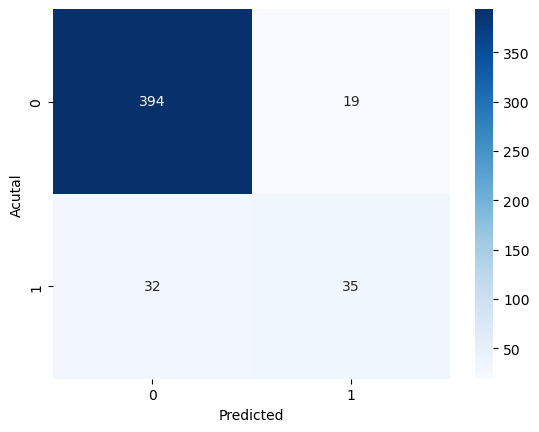

In [19]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted");plt.ylabel("Acutal")
plt.show()

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_balanced = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    max_features="sqrt",
    random_state=42,
    class_weight="balanced"  
    
)

rf_balanced.fit(x_train, y_train)
y_pred=rf_balanced.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94       413
           1       0.70      0.48      0.57        67

    accuracy                           0.90       480
   macro avg       0.81      0.72      0.75       480
weighted avg       0.89      0.90      0.89       480



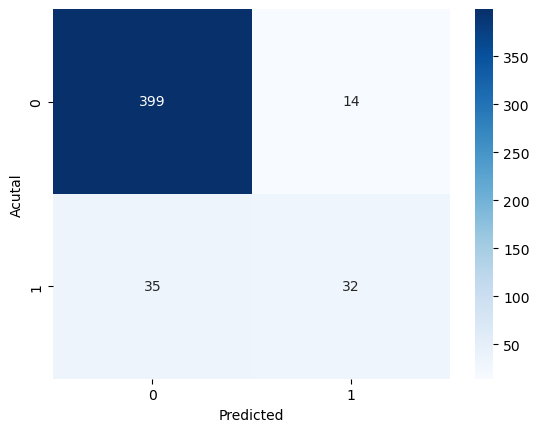

In [21]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted");plt.ylabel("Acutal")
plt.show()

In [22]:
from sklearn.metrics import precision_recall_curve
y_probs=rf.predict_proba(x_test)[:,1]

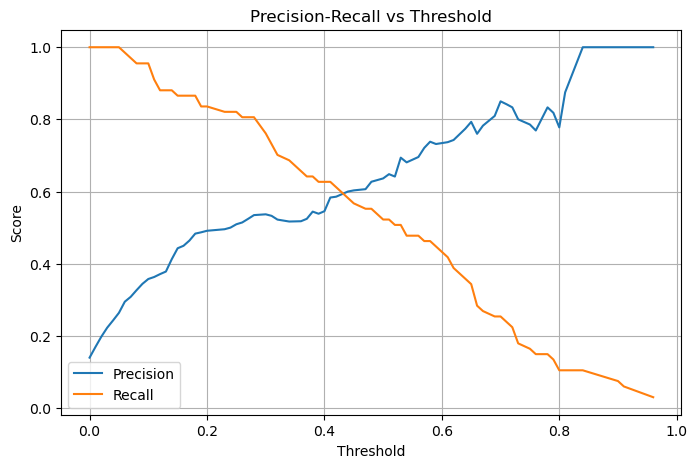

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

y_probs = rf.predict_proba(x_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(8,5))

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold")
plt.legend()
plt.grid(True)

plt.show()

In [24]:
# Threshold = 0.30
y_pred_30 = (y_proba >= 0.30).astype(int)
print(classification_report(y_test, y_pred_30))

# Threshold = 0.45
y_pred_45 = (y_proba >= 0.45).astype(int)
print(classification_report(y_test, y_pred_45))

# Threshold = 0.60
y_pred_60 = (y_proba >= 0.60).astype(int)
print(classification_report(y_test, y_pred_60))

              precision    recall  f1-score   support

           0       0.96      0.89      0.92       413
           1       0.54      0.76      0.63        67

    accuracy                           0.88       480
   macro avg       0.75      0.83      0.78       480
weighted avg       0.90      0.88      0.88       480

              precision    recall  f1-score   support

           0       0.93      0.94      0.93       413
           1       0.60      0.57      0.58        67

    accuracy                           0.89       480
   macro avg       0.77      0.75      0.76       480
weighted avg       0.88      0.89      0.89       480

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       413
           1       0.74      0.42      0.53        67

    accuracy                           0.90       480
   macro avg       0.82      0.70      0.74       480
weighted avg       0.89      0.90      0.89       480



In [25]:
importance=rf.feature_importances_
feat_importances=pd.Series(importance,index=x.columns).sort_values(ascending=False)

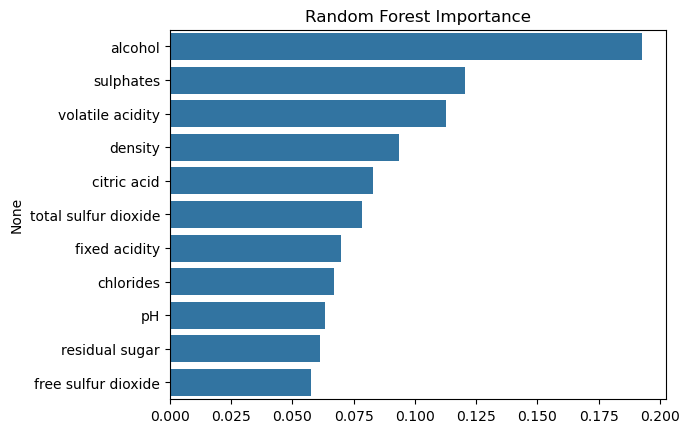

In [26]:
sns.barplot(x=feat_importances.values,y=feat_importances.index)
plt.title("Random Forest Importance")
plt.show()

In [27]:
param_grid={
    "n_estimators":[100,200],
    "max_depth":[None,10,20],
    "min_samples_split":[2,5]
}

In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

In [29]:
grid.fit(x_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
0.8894840041279669


In [30]:
print(data["Target"].value_counts())

Target
0    1382
1     217
Name: count, dtype: int64


In [31]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Features & Target
X = data.drop('Target', axis=1)
y = data['Target']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


sm = SMOTE(random_state=42)

X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

In [32]:
pd.Series(y_train_sm).value_counts()

Target
0    1105
1    1105
Name: count, dtype: int64